# Morphological Blemish Analysis for Mango Ripeness Assessment
### Course: BMDS2133 Image Processing | Assignment Mode A: Comparative & Enhancement Study
**Developer:** Cham Herman (hm)  
**Module:** Morphological Blemish Analysis (Morphology-Based)  
**Dataset:** `cleaned_data` (Standardised Background-Removed Mango Dataset, 715 images)

---

## Overview & Objectives

### Ripeness Progression on Mango Skin
- **Unripe:** Smooth, uniform green skin with negligible surface blemishes.
- **Fully Ripe:** Yellow skin with minor, scattered natural freckles (lenticels).
- **Overripe:** Dark necrotic lesions, fungal decay patches, and heavy blemish clusters.

**Core Idea:** Use mathematical morphology to detect and measure surface blemishes for ripeness classification.

### Technical Objectives
1. **[Comparative Study]:** Implement and benchmark 4 classical mathematical morphology algorithms for blemish detection.
2. **[Quantitative Benchmarking]:** Measure Classification Accuracy, Macro F1-Score, and Latency across 715 images (Target: Accuracy >= 85%, Latency < 200 ms).
3. **[Enhancement & Hybrid Solution]:** Build Multi-Representation Morphological Fusion (MRMF) to enrich feature representation and exceed baseline accuracy.
4. **[Prototype Integration]:** Export the trained model for integration into the Streamlit prototype.


## 1. [Configuration] Environment Setup & Parameters
**Why:** Import required image processing and machine learning libraries (`OpenCV`, `scikit-image`, `scikit-learn`), set random seed (42) for experimental reproducibility, and configure dataset and output directories.


In [47]:
import os
import glob
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from skimage import morphology as skm, measure as skmeas
from scipy import ndimage as ndi
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from IPython.display import Markdown, display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import joblib

# Set random seed for experimental reproducibility
np.random.seed(42)

# --- Path Configurations ---
DATASET_ROOT = '../cleaned_data'
OUTPUT_DIR = '../output/morphology_based'
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIG_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

CLASSES = ['unripe', 'fully_ripe', 'overripe']
CLASS_COLORS = {'unripe': '#2ca02c', 'fully_ripe': '#ff7f0e', 'overripe': '#d62728'}

print("Dataset root directory:", os.path.abspath(DATASET_ROOT))
print("      Output directory:", os.path.abspath(OUTPUT_DIR))
print("        Target classes:", CLASSES)


Dataset root directory: c:\repository\mango-ripeness-grading\cleaned_data
      Output directory: c:\repository\mango-ripeness-grading\output\morphology_based
        Target classes: ['unripe', 'fully_ripe', 'overripe']


## 2. [Dataset Inspection] Verification of Class Distributions
**Why:** Verify that image counts across the 3 ripeness classes (`unripe`, `fully_ripe`, `overripe`) are balanced across training (571 images) and testing (144 images) splits to prevent model bias.


Dataset Summary Table:


,Split,Class,Image Count
0,train,unripe,190
1,train,fully_ripe,189
2,train,overripe,192
3,test,unripe,48
4,test,fully_ripe,48
5,test,overripe,48


Total Dataset Size: 715 images (Train: 571, Test: 144)


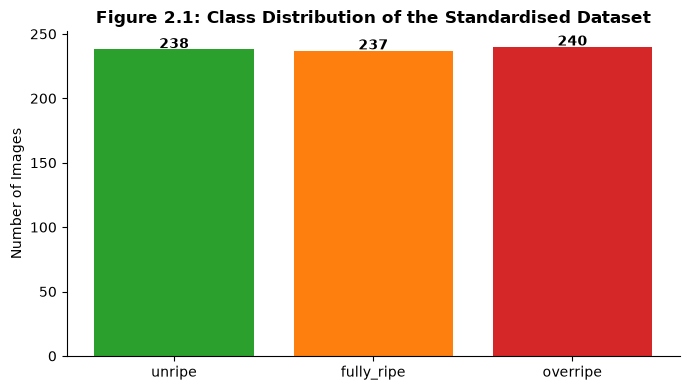

In [48]:
dataset_summary = []
for split in ['train', 'test']:
    for cls in CLASSES:
        pattern = os.path.join(DATASET_ROOT, split, cls, '*.*')
        paths = glob.glob(pattern)
        dataset_summary.append({
            'Split': split,
            'Class': cls,
            'Image Count': len(paths)
        })

df_summary = pd.DataFrame(dataset_summary)
print("Dataset Summary Table:")
display(df_summary)

total_images = df_summary['Image Count'].sum()
train_count = df_summary[df_summary['Split']=='train']['Image Count'].sum()
test_count = df_summary[df_summary['Split']=='test']['Image Count'].sum()
print(f"Total Dataset Size: {total_images} images (Train: {train_count}, Test: {test_count})")


# Figure 2.1: class distribution of the standardised dataset
fig_dist, ax_dist = plt.subplots(figsize=(7, 4))
class_totals = df_summary.groupby('Class')['Image Count'].sum().reindex(CLASSES)
bars = ax_dist.bar(class_totals.index, class_totals.values,
                   color=[CLASS_COLORS.get(c, '#999') for c in class_totals.index])
for b, v in zip(bars, class_totals.values):
    ax_dist.text(b.get_x() + b.get_width() / 2, v + 1, str(int(v)), ha='center', fontweight='bold')
ax_dist.set_ylabel("Number of Images")
ax_dist.set_title("Figure 2.1: Class Distribution of the Standardised Dataset", fontsize=12, fontweight='bold')
ax_dist.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_1_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. [Preprocessing] Fruit Masking and Boundary Ring Erosion

**Why:**
Before detecting blemishes on the fruit, we must:
1. Isolate the mango from the black background.
2. Exclude the outer boundary edge, which appears artificially dark due to lighting falloff and can cause false blemish detections.

**Steps:**
1. **Fruit Masking:** Separate the mango from the black background using an intensity threshold ($\text{Pixel} > 20$).
2. **Morphological Cleaning:** Remove stray background noise with Opening and seal internal holes with Closing.
3. **Boundary Ring Erosion:** Erode the mask boundary inward with an elliptical kernel ($\text{Mask} \ominus \text{Kernel}$) to eliminate border transition artifacts. All subsequent blemish analysis is restricted to this safe interior mask.


In [49]:
def get_fruit_mask(img_bgr, thresh=20):
    """Extract and clean foreground mango mask from black background."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = (gray > thresh).astype(np.uint8) * 255
    se_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, se_clean)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, se_clean)
    return mask

def get_interior_mask(mask, k=13):
    """Erode mango mask to eliminate boundary transition ring."""
    se_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    return cv2.erode(mask, se_erode)


### Visualisation: Preprocessing & Fruit Mask Boundary Erosion
**Goal:** Visually confirm clean separation of the fruit and safe exclusion of boundary transition edges.


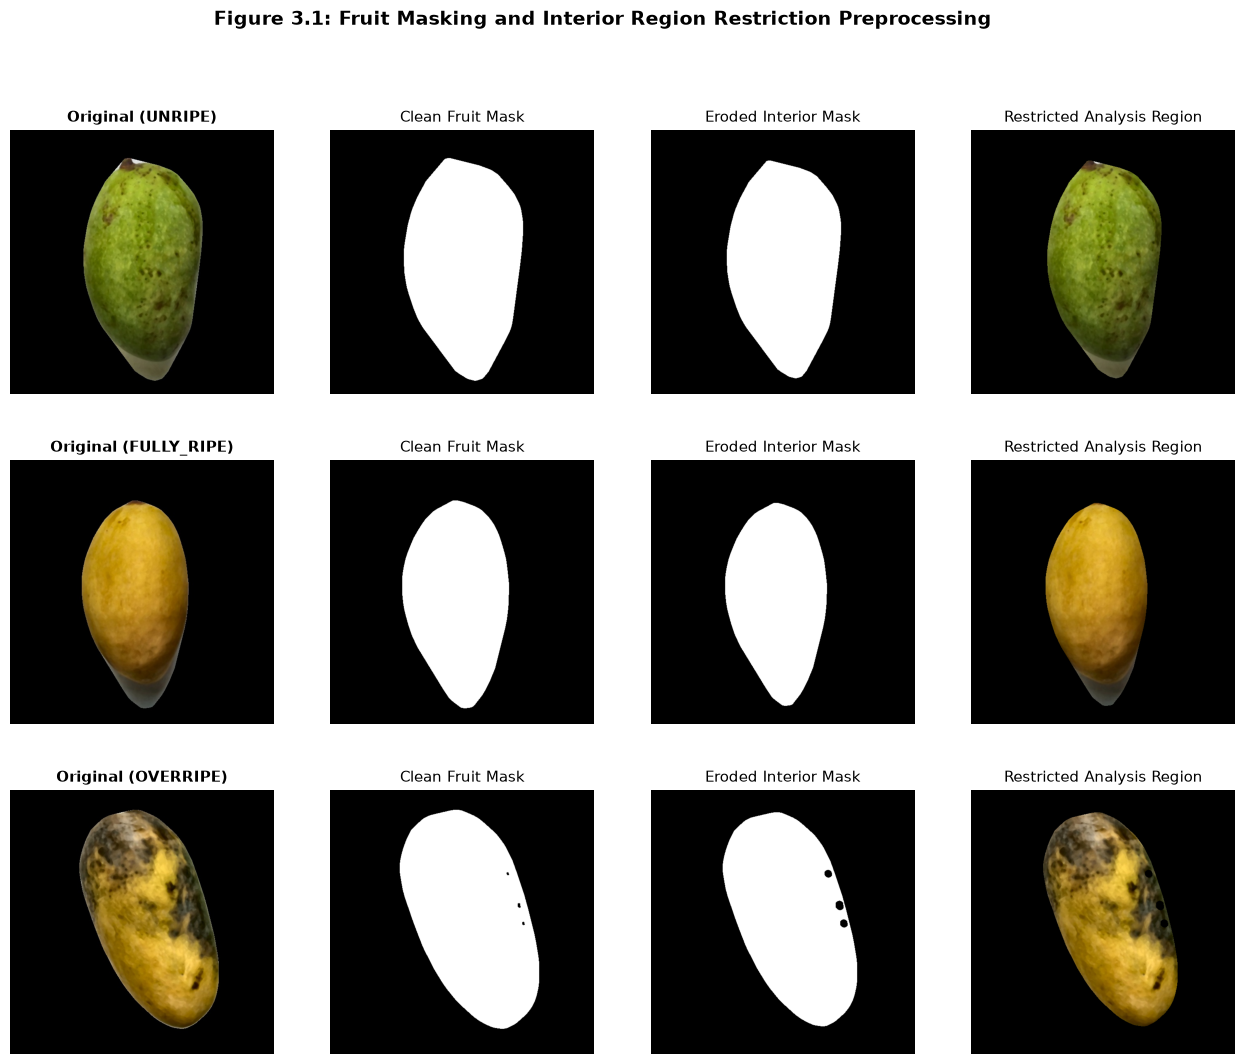

<Figure size 640x480 with 0 Axes>

In [50]:
sample_images = {}
for cls in CLASSES:
    sample_path = glob.glob(os.path.join(DATASET_ROOT, 'test', cls, '*.jpg'))[0]
    sample_images[cls] = (cv2.imread(sample_path), sample_path)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
plt.subplots_adjust(wspace=0.15, hspace=0.25)

for row_idx, cls in enumerate(CLASSES):
    img_bgr, path = sample_images[cls]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mask = get_fruit_mask(img_bgr)
    interior = get_interior_mask(mask)
    
    masked_mango = cv2.bitwise_and(img_rgb, img_rgb, mask=interior)
    
    axes[row_idx, 0].imshow(img_rgb)
    axes[row_idx, 0].set_title(f"Original ({cls.upper()})", fontsize=11, fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow(mask, cmap='gray')
    axes[row_idx, 1].set_title("Clean Fruit Mask", fontsize=11)
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(interior, cmap='gray')
    axes[row_idx, 2].set_title("Eroded Interior Mask", fontsize=11)
    axes[row_idx, 2].axis('off')
    
    axes[row_idx, 3].imshow(masked_mango)
    axes[row_idx, 3].set_title("Restricted Analysis Region", fontsize=11)
    axes[row_idx, 3].axis('off')

plt.suptitle("Figure 3.1: Fruit Masking and Interior Region Restriction Preprocessing", fontsize=14, fontweight='bold', y=0.98)
plt.show()

plt.savefig(os.path.join(FIG_DIR, 'fig3_1_fruit_masking.png'), dpi=150, bbox_inches='tight')


## 3A. [Preprocessing v2] Background-Agnostic Morphological Fruit Masking (Raw Images & Live Inputs)

**Why:**
The benchmark images use standardized black backgrounds, but real-world inputs (such as mobile cameras or live webcams) contain arbitrary backgrounds, surfaces, and shadows. This module provides a robust morphological fruit segmenter without requiring deep learning.

**Methodology:**
1. **Color & Saturation Filtering:** Mango skin exhibits strong chromatic saturation across ripe and unripe states, whereas background shadows are desaturated. A saturation floor cleanly filters out shadows.
2. **Morphological Consolidation:** Connects fragmented fruit regions, fills interior holes caused by dark lesions, and retains the largest connected component.
3. **Boundary Smoothing:** Smooths the contour and applies interior erosion to exclude border artifacts.


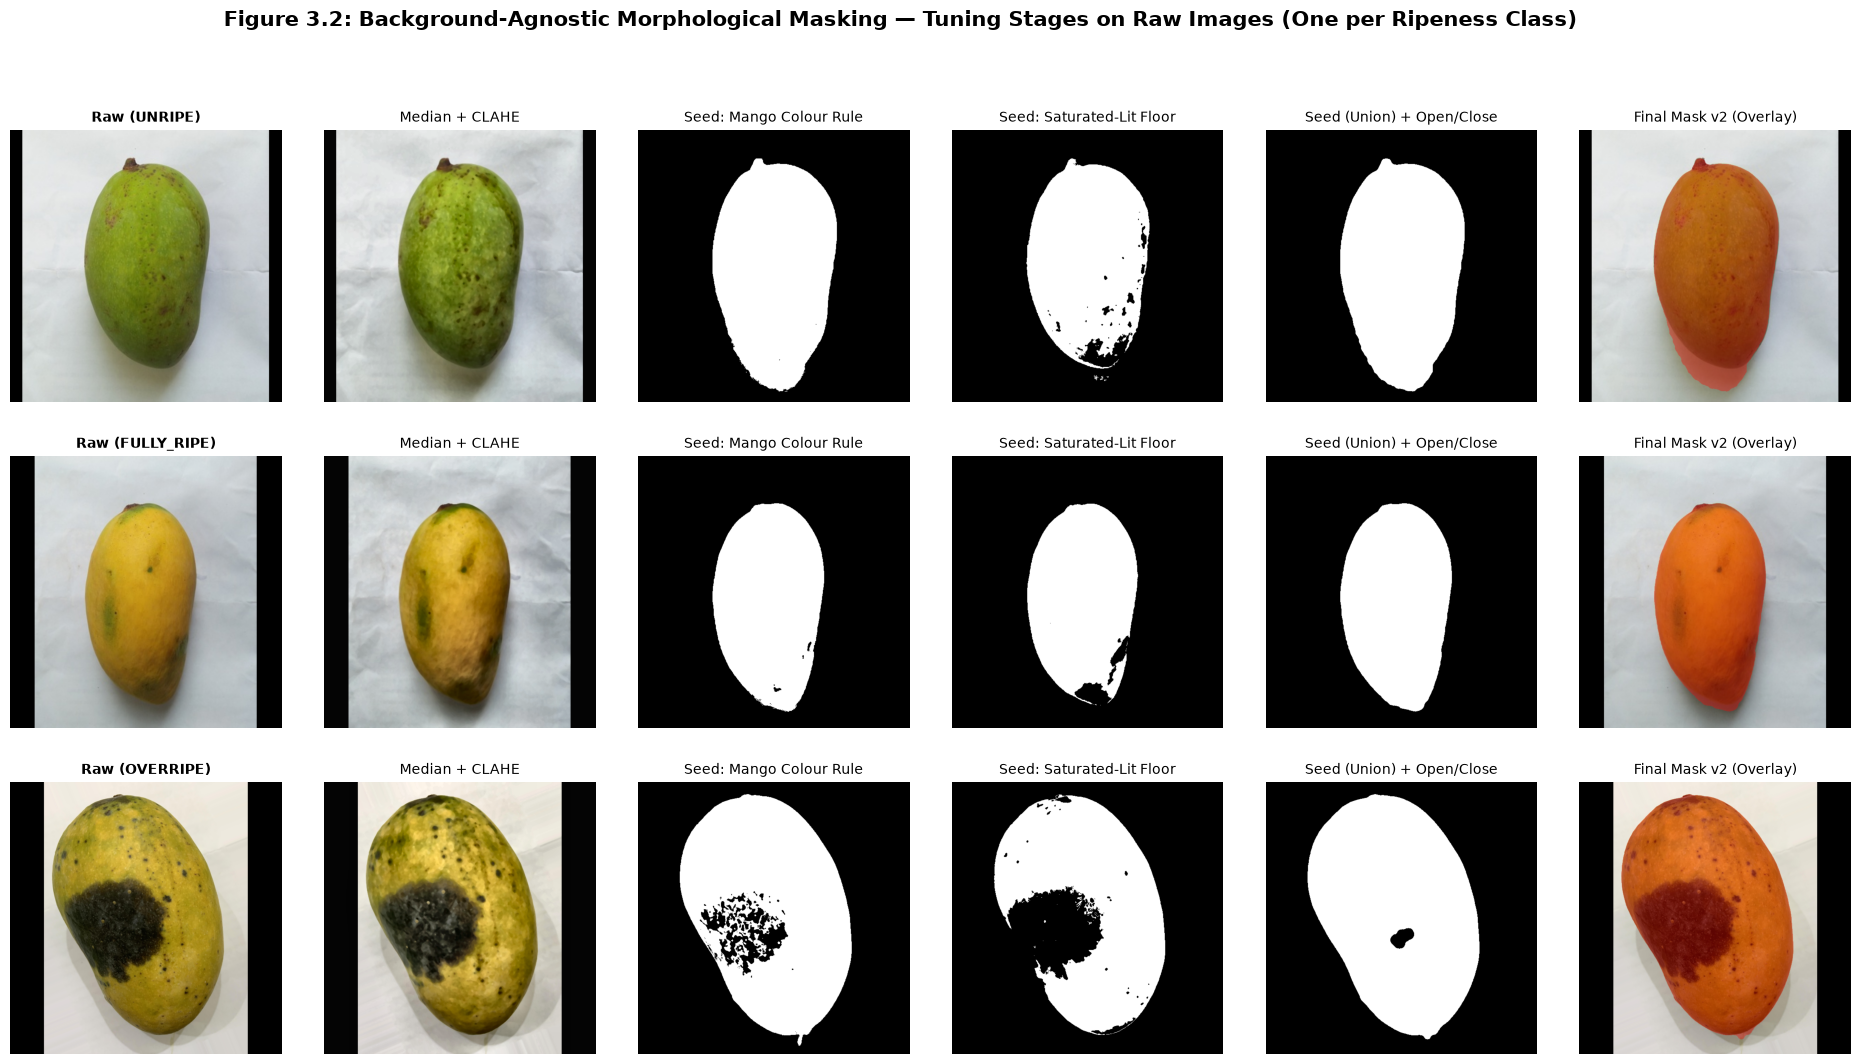

<Figure size 640x480 with 0 Axes>

In [51]:
# ----- Background-agnostic morphological fruit mask -----
def _ellipse(size):
    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))


def _fill_holes(mask):
    """Border flood-fill: any region NOT reachable from the image border is an
    interior hole and is filled."""
    h, w = mask.shape
    ff = cv2.bitwise_not(mask)
    ffmask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(ff, ffmask, (0, 0), 0)
    return cv2.bitwise_or(mask, ff)


def segment_fruit_mask_v2(img_bgr, return_stages=False):
    """Background-agnostic morphological fruit segmentation .

    Input: raw BGR photograph (any background). Output: 640x640 uint8 mask."""
    # 1. Standardisation (letterbox -> median blur -> CLAHE)
    img = letterbox_640(img_bgr)
    img = cv2.medianBlur(img, 5)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)
    l_ch = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l_ch)
    img = cv2.cvtColor(cv2.merge((l_ch, a_ch, b_ch)), cv2.COLOR_LAB2BGR)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 2. Fruit-likelihood seed
    color_rule = cv2.inRange(hsv, (0, 50, 40), (95, 255, 255)) | \
                 cv2.inRange(hsv, (170, 60, 40), (180, 255, 255))
    sat_val_floor = cv2.inRange(hsv, (0, 100, 60), (180, 255, 255))
    seed = cv2.bitwise_or(color_rule, sat_val_floor)

    # 3. Morphological consolidation
    seed = cv2.morphologyEx(seed, cv2.MORPH_CLOSE, _ellipse(25))
    seed = cv2.morphologyEx(seed, cv2.MORPH_OPEN, _ellipse(15))
    nb, labels, stats, _ = cv2.connectedComponentsWithStats(seed, connectivity=8)
    if nb <= 1:
        return (np.zeros((640, 640), np.uint8), {'img': img, 'seed': seed}) if return_stages \
            else np.zeros((640, 640), np.uint8)
    largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    fruit = (labels == largest).astype(np.uint8) * 255

    # 4-5. Hole removal and boundary smoothing
    fruit = _fill_holes(fruit)
    fruit = cv2.morphologyEx(fruit, cv2.MORPH_OPEN, _ellipse(7))
    fruit = cv2.morphologyEx(fruit, cv2.MORPH_CLOSE, _ellipse(7))

    if return_stages:
        return fruit, {'img': img, 'color_rule': color_rule,
                       'sat_val_floor': sat_val_floor, 'seed': seed}
    return fruit


def letterbox_640(img_bgr, size=640):
    h, w = img_bgr.shape[:2]
    scale = min(size / h, size / w)
    nh, nw = max(int(h * scale), 1), max(int(w * scale), 1)
    resized = cv2.resize(img_bgr, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((size, size, 3), dtype=np.uint8)
    top, left = (size - nh) // 2, (size - nw) // 2
    canvas[top:top + nh, left:left + nw] = resized
    return canvas


DATA_RAW = '../data'
TUNING_IMAGES = {
    'unripe': os.path.join(DATA_RAW, 'unripe', 'IMG20200713141551.jpg'),
    'fully_ripe': os.path.join(DATA_RAW, 'fully_ripe', 'IMG20200717083337.jpg'),
    'overripe': os.path.join(DATA_RAW, 'overripe', 'image_0_1014.jpg'),
}

fig, axes = plt.subplots(3, 6, figsize=(24, 12))
plt.subplots_adjust(wspace=0.08, hspace=0.2)

for row_idx, (cls, path) in enumerate(TUNING_IMAGES.items()):
    raw = cv2.imread(path)
    lb = letterbox_640(raw)
    mask_v2, st = segment_fruit_mask_v2(raw, return_stages=True)

    rgb = cv2.cvtColor(lb, cv2.COLOR_BGR2RGB)
    overlay = rgb.copy()
    overlay[mask_v2 > 0] = [255, 0, 0]
    blended = cv2.addWeighted(rgb, 0.65, overlay, 0.35, 0)

    panels = [
        (rgb, f"Raw ({cls.upper()})"),
        (cv2.cvtColor(st['img'], cv2.COLOR_BGR2RGB), "Median + CLAHE"),
        (st['color_rule'], "Seed: Mango Colour Rule"),
        (st['sat_val_floor'], "Seed: Saturated-Lit Floor"),
        (st['seed'], "Seed (Union) + Open/Close"),
        (blended, "Final Mask v2 (Overlay)"),
    ]
    for col, (panel, title) in enumerate(panels):
        ax = axes[row_idx, col]
        ax.imshow(panel, cmap='gray' if panel.ndim == 2 else None)
        ax.set_title(title, fontsize=10, fontweight='bold' if col == 0 else 'normal')
        ax.axis('off')

plt.suptitle("Figure 3.2: Background-Agnostic Morphological Masking — Tuning Stages on Raw Images (One per Ripeness Class)",
             fontsize=15, fontweight='bold', y=0.98)
plt.show()
plt.savefig(os.path.join(FIG_DIR, 'fig3_2_tierb_masking_stages.png'), dpi=150, bbox_inches='tight')


### Validation Against the Standardised Dataset
**Why:** Validate the background-agnostic mask against reference masks from the standardized dataset to verify boundary accuracy.
- **Metric:** **Intersection-over-Union (IoU)** measures spatial overlap against the reference fruit silhouette ($1.0 = \text{perfect match}$).


In [52]:
import sys
print("Validating background-agnostic masking on all raw dataset images (image-by-image streaming)...")
sys_path_backup = list(sys.path)
sys.path.insert(0, '..')
from src.preprocessing import remove_background as _kmeans_remove_background

iou_scores = {cls: [] for cls in CLASSES}
overfilled_refs = {cls: 0 for cls in CLASSES}
n_processed = 0
n_cleaned_twins = 0
masker_time = 0.0
kmeans_time = 0.0
kmeans_samples = 0
low_cov = 0

for cls in CLASSES:
    raw_paths = sorted(glob.glob(os.path.join(DATA_RAW, cls, '*.jpg')) +
                       glob.glob(os.path.join(DATA_RAW, cls, '*.png')))
    for rp in raw_paths:
        name = os.path.basename(rp)
        img = cv2.imread(rp)
        if img is None:
            continue
        n_processed += 1

        t0 = time.perf_counter()
        mask_v2 = segment_fruit_mask_v2(img)
        masker_time += time.perf_counter() - t0
        coverage = mask_v2.mean() / 255.0
        if coverage < 0.03 or coverage > 0.97:
            low_cov += 1

        if kmeans_samples < 50:
            t0 = time.perf_counter()
            _kmeans_remove_background(letterbox_640(img))
            kmeans_time += time.perf_counter() - t0
            kmeans_samples += 1

        cleaned_path = None
        for split in ('train', 'test'):
            cand = os.path.join(DATASET_ROOT, split, cls, name)
            if os.path.exists(cand):
                cleaned_path = cand
                break
        if cleaned_path is None:
            continue
        n_cleaned_twins += 1

        m_ref = get_fruit_mask(cv2.imread(cleaned_path))
        if (m_ref > 0).sum() > 0.5 * 640 * 640:
            overfilled_refs[cls] += 1
        inter = np.logical_and(mask_v2 > 0, m_ref > 0).sum()
        union = np.logical_or(mask_v2 > 0, m_ref > 0).sum()
        iou_scores[cls].append(inter / union if union else 1.0)

sys.path = sys_path_backup

rows = []
for cls in CLASSES:
    arr = np.array(iou_scores[cls])
    rows.append({
        'Class': cls,
        'Paired Images': len(arr),
        'IoU Mean (%)': round(arr.mean() * 100, 2),
        'IoU Std (%)': round(arr.std() * 100, 2),
        'IoU < 80% (count)': int((arr < 0.8).sum()),
        'Over-filled Reference (count)': overfilled_refs[cls],
    })
all_arr = np.concatenate([np.array(iou_scores[c]) for c in CLASSES])
rows.append({
    'Class': 'TOTAL', 'Paired Images': len(all_arr),
    'IoU Mean (%)': round(all_arr.mean() * 100, 2), 'IoU Std (%)': round(all_arr.std() * 100, 2),
    'IoU < 80% (count)': int((all_arr < 0.8).sum()),
    'Over-filled Reference (count)': sum(overfilled_refs.values()),
})
df_mask_val = pd.DataFrame(rows)
print("Background-Agnostic Masking Validation (agreement with the standardised masks + reference audit):")
display(df_mask_val)

print(f"Raw images processed: {n_processed}/883 | implausible mask coverage (<3% or >97%): {low_cov}")
print(f"Morphological masker:  {masker_time / max(n_processed, 1) * 1000:.1f} ms/image")
print(f"K-Means remove_background:    {kmeans_time / max(kmeans_samples, 1) * 1000:.1f} ms/image  (measured on {kmeans_samples} images)")
print("Low-agreement cases are dominated by over-filled references (reference audit column): the")
print("       K-Means convex hull can retain the cast shadow, a holding hand, or background wedges, which")
print("       the morphological masker removes — see the disagreement inspection above.")
df_mask_val.to_csv(os.path.join(OUTPUT_DIR, 'mask_validation.csv'), index=False)


Validating background-agnostic masking on all raw dataset images (image-by-image streaming)...
Background-Agnostic Masking Validation (agreement with the standardised masks + reference audit):


,Class,Paired Images,IoU Mean (%),IoU Std (%),IoU < 80% (count),Over-filled Reference (count)
0,unripe,238,94.25,3.47,1,1
1,fully_ripe,237,95.34,1.47,0,0
2,overripe,240,90.21,12.35,50,32
3,TOTAL,715,93.26,7.80,51,33


Raw images processed: 883/883 | implausible mask coverage (<3% or >97%): 0
Morphological masker:  13.7 ms/image
K-Means remove_background:    251.2 ms/image  (measured on 50 images)
Low-agreement cases are dominated by over-filled references (reference audit column): the
       K-Means convex hull can retain the cast shadow, a holding hand, or background wedges, which
       the morphological masker removes — see the disagreement inspection above.


## 4. [Methodology] Implementation of 4 Distinct Baseline Morphological Algorithms

**Why:** Evaluate 4 distinct classical morphology techniques to identify the most effective method for blemish segmentation:

---

### Algorithm 1: Grayscale Morphological Filtering (Open-Close Residual)
- **Principle:** Closing fills localized dark valleys (blemishes); Opening suppresses bright reflections. Subtracting them isolates surface variations.
- **Formula:** $\text{Diff} = \text{Closed Image} - \text{Opened Image}$

---

### Algorithm 2: Dual Top-Hat & Black-Hat Transformation
- **Principle:** Black-Hat extracts dark necrotic lesions; White Top-Hat extracts pale fungal or sap patches.
- **Formula:**
  - $\text{Black-Hat} = \text{Closed Image} - \text{Original}$
  - $\text{Top-Hat} = \text{Original} - \text{Opened Image}$

---

### Algorithm 3: Morphological Gradient Delineation (Beucher Gradient)
- **Principle:** Dilation expands bright structures while Erosion shrinks them. Subtracting them highlights steep intensity transitions at blemish boundaries.
- **Formula:** $\text{Gradient} = \text{Dilation} - \text{Erosion}$

---

### Algorithm 4: Marker-Controlled Morphological Watershed
- **Principle:** Treats gradient intensity as a topographic surface. Floods regional minima marker seeds to separate touching or clustered blemish regions.


In [53]:
# -------------------------------------------------------------------------
# Algorithm 1: Grayscale Open-Close Residual Filtering
# -------------------------------------------------------------------------
def run_alg1_morph_filter(gray, interior):
    """Algorithm 1: Grayscale Opening followed by Closing residual."""
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, se)
    opened = cv2.morphologyEx(gray, cv2.MORPH_OPEN, se)
    diff = cv2.subtract(closed, opened)
    diff = cv2.bitwise_and(diff, diff, mask=interior)
    
    vals = diff[interior > 0]
    if len(vals) == 0 or vals.max() == 0:
        bw = np.zeros_like(gray)
    else:
        thresh_val = max(np.percentile(vals, 90), 20)
        _, bw = cv2.threshold(diff, thresh_val, 255, cv2.THRESH_BINARY)
    
    bw = cv2.bitwise_and(bw, bw, mask=interior)
    return bw, {'closed': closed, 'opened': opened, 'diff': diff}

# -------------------------------------------------------------------------
# Algorithm 2: Dual Top-Hat & Black-Hat Transformation
# -------------------------------------------------------------------------
def run_alg2_tophat_blackhat(gray, interior):
    """Algorithm 2: Black-Hat (dark lesions) + White Top-Hat (pale patches)."""
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, se)
    white_hat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, se)
    
    black_hat = cv2.bitwise_and(black_hat, black_hat, mask=interior)
    white_hat = cv2.bitwise_and(white_hat, white_hat, mask=interior)
    
    _, bw_dark = cv2.threshold(black_hat, 25, 255, cv2.THRESH_BINARY)
    _, bw_bright = cv2.threshold(white_hat, 35, 255, cv2.THRESH_BINARY)
    
    bw = cv2.bitwise_or(bw_dark, bw_bright)
    bw = cv2.bitwise_and(bw, bw, mask=interior)
    return bw, {'black_hat': black_hat, 'white_hat': white_hat}

# -------------------------------------------------------------------------
# Algorithm 3: Morphological Gradient Delineation
# -------------------------------------------------------------------------
def run_alg3_morph_gradient(gray, interior):
    """Algorithm 3: Beucher Morphological Gradient (Dilation - Erosion)."""
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    dilated = cv2.dilate(gray, se)
    eroded = cv2.erode(gray, se)
    grad = cv2.subtract(dilated, eroded)
    grad = cv2.bitwise_and(grad, grad, mask=interior)
    
    vals = grad[interior > 0]
    if len(vals) == 0 or vals.max() == 0:
        bw = np.zeros_like(gray)
    else:
        thresh_val = max(np.percentile(vals, 92), 25)
        _, bw = cv2.threshold(grad, thresh_val, 255, cv2.THRESH_BINARY)
        
    se_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, se_close)
    bw = cv2.bitwise_and(bw, bw, mask=interior)
    return bw, {'dilated': dilated, 'eroded': eroded, 'grad': grad}

# -------------------------------------------------------------------------
# Algorithm 4: Marker-Controlled Morphological Watershed
# -------------------------------------------------------------------------
def run_alg4_marker_watershed(gray, interior):
    """Algorithm 4: Marker-Controlled Watershed on Morphological Gradient."""
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, se)
    black_hat = cv2.bitwise_and(black_hat, black_hat, mask=interior)
    _, bw_cand = cv2.threshold(black_hat, 25, 255, cv2.THRESH_BINARY)
    
    se_grad = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    grad = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, se_grad)
    grad = cv2.bitwise_and(grad, grad, mask=interior)
    
    dist = cv2.distanceTransform(bw_cand, cv2.DIST_L2, 5)
    if dist.max() > 1.0:
        _, seeds = cv2.threshold(dist, 0.4 * dist.max(), 255, 0)
        num_markers, markers = cv2.connectedComponents(seeds.astype(np.uint8))
        markers = markers + 1
        markers[interior == 0] = 0
        
        grad_bgr = cv2.cvtColor(grad, cv2.COLOR_GRAY2BGR)
        markers = cv2.watershed(grad_bgr, markers)
        bw = np.zeros_like(gray)
        bw[(markers > 1) & (bw_cand > 0) & (interior > 0)] = 255
    else:
        bw = np.zeros_like(gray)
        markers = np.zeros_like(gray, dtype=np.int32)
        
    return bw, {'grad': grad, 'bw_cand': bw_cand, 'markers': markers}


### Visualisation: Blemish Segmentation Across the 4 Morphological Baselines
**Goal:** Visually compare blemish segmentation masks across all 4 baseline algorithms on representative sample images.


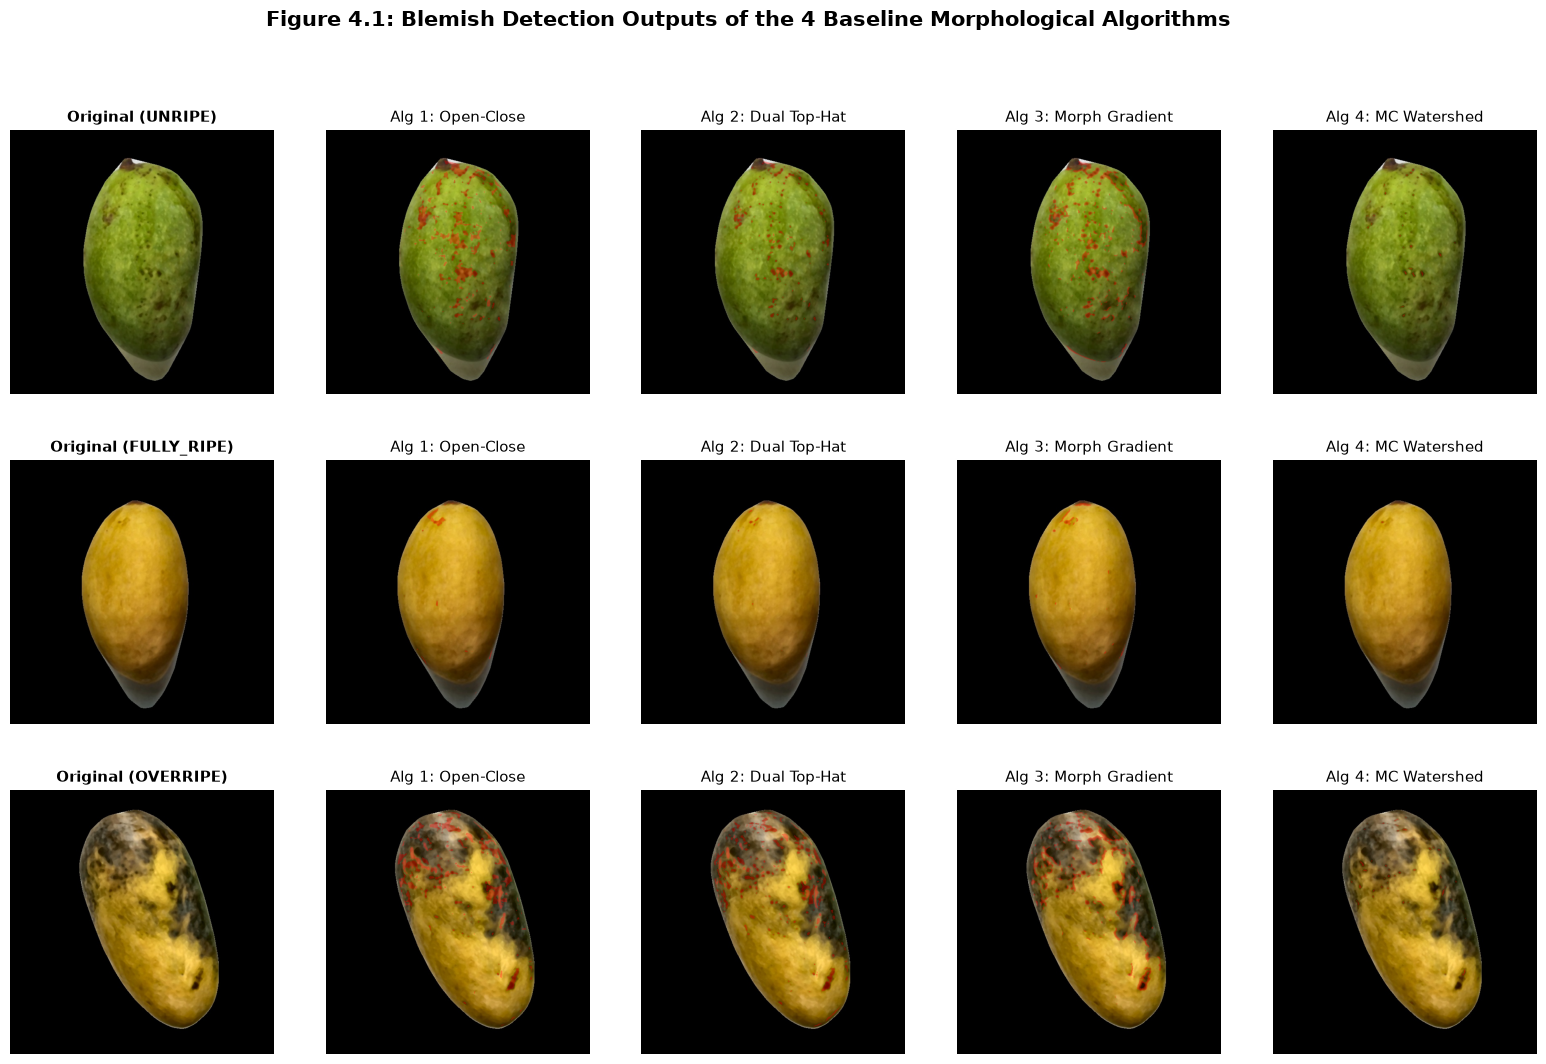

<Figure size 640x480 with 0 Axes>

In [54]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
plt.subplots_adjust(wspace=0.1, hspace=0.25)

for row_idx, cls in enumerate(CLASSES):
    img_bgr, _ = sample_images[cls]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = get_fruit_mask(img_bgr)
    interior = get_interior_mask(mask)
    
    bw1, _ = run_alg1_morph_filter(gray, interior)
    bw2, _ = run_alg2_tophat_blackhat(gray, interior)
    bw3, _ = run_alg3_morph_gradient(gray, interior)
    bw4, _ = run_alg4_marker_watershed(gray, interior)
    
    def create_overlay(rgb, bw):
        overlay = rgb.copy()
        overlay[bw > 0] = [255, 0, 0] # Highlight blemishes in red
        return cv2.addWeighted(rgb, 0.65, overlay, 0.35, 0)
    
    axes[row_idx, 0].imshow(img_rgb)
    axes[row_idx, 0].set_title(f"Original ({cls.upper()})", fontsize=11, fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow(create_overlay(img_rgb, bw1))
    axes[row_idx, 1].set_title("Alg 1: Open-Close", fontsize=11)
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(create_overlay(img_rgb, bw2))
    axes[row_idx, 2].set_title("Alg 2: Dual Top-Hat", fontsize=11)
    axes[row_idx, 2].axis('off')
    
    axes[row_idx, 3].imshow(create_overlay(img_rgb, bw3))
    axes[row_idx, 3].set_title("Alg 3: Morph Gradient", fontsize=11)
    axes[row_idx, 3].axis('off')
    
    axes[row_idx, 4].imshow(create_overlay(img_rgb, bw4))
    axes[row_idx, 4].set_title("Alg 4: MC Watershed", fontsize=11)
    axes[row_idx, 4].axis('off')

plt.suptitle("Figure 4.1: Blemish Detection Outputs of the 4 Baseline Morphological Algorithms", fontsize=15, fontweight='bold', y=0.98)
plt.show()

plt.savefig(os.path.join(FIG_DIR, 'fig4_1_baseline_blemish_outputs.png'), dpi=150, bbox_inches='tight')


## 5. [Feature Extraction] Standardised Morphological Feature Vector

**Why:**
Classifiers require numerical representations rather than raw pixel masks. We extract a 10-dimensional morphological statistical feature vector for each image:

| Category | Feature Name | Description |
| :--- | :--- | :--- |
| **Count & Area** | `n_blemishes`, `blemish_area`, `area_ratio` | Total blemish count, total blemish pixel area, and area percentage of fruit surface ($\frac{\text{Blemish Area}}{\text{Fruit Area}} \times 100\%$) |
| **Intensity** | `mean_darkness`, `max_darkness`, `mean_brightness` | Average darkness, peak darkness, and mean brightness within blemish regions |
| **Geometry** | `mean_aspect_ratio`, `mean_solidity`, `skeleton_length` | Average elongation, solidity, and morphological skeleton length capturing decay streaks |
| **Distribution** | `blemish_dispersion` | Spatial standard deviation of blemish centroids relative to the fruit center |


In [55]:
def extract_morphological_features(gray, bw_blemish, interior_mask, interior_area):
    """Extract standardised 10-dimensional morphological feature vector."""
    feats = {
        'n_blemishes': 0,
        'blemish_area': 0,
        'area_ratio': 0.0,
        'mean_darkness': 0.0,
        'max_darkness': 0.0,
        'mean_brightness': 0.0,
        'mean_aspect_ratio': 0.0,
        'mean_solidity': 0.0,
        'skeleton_length': 0,
        'blemish_dispersion': 0.0
    }
    
    if interior_area == 0:
        return feats

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bw_blemish, connectivity=8)
    if num_labels <= 1:
        return feats

    areas = stats[1:, cv2.CC_STAT_AREA]
    widths = stats[1:, cv2.CC_STAT_WIDTH]
    heights = stats[1:, cv2.CC_STAT_HEIGHT]
    
    feats['n_blemishes'] = int(num_labels - 1)
    feats['blemish_area'] = int(np.sum(areas))
    feats['area_ratio'] = float((feats['blemish_area'] / interior_area) * 100.0)

    blemish_pixels = gray[bw_blemish > 0]
    if len(blemish_pixels) > 0:
        feats['mean_darkness'] = float(np.mean(255.0 - blemish_pixels))
        feats['max_darkness'] = float(np.max(255.0 - blemish_pixels))
        feats['mean_brightness'] = float(np.mean(blemish_pixels))

    aspect_ratios = np.maximum(widths, heights) / (np.minimum(widths, heights) + 1e-5)
    feats['mean_aspect_ratio'] = float(np.mean(aspect_ratios))
    
    bbox_areas = widths * heights
    solidity_est = areas / (bbox_areas + 1e-5)
    feats['mean_solidity'] = float(np.mean(np.clip(solidity_est, 0.0, 1.0)))

    if len(centroids) > 1:
        c_pts = centroids[1:]
        fruit_center = np.mean(c_pts, axis=0)
        disp = np.mean(np.linalg.norm(c_pts - fruit_center, axis=1))
        feats['blemish_dispersion'] = float(disp)

    # Fast morphological skeletonization via iterative thinning
    skel = np.zeros(bw_blemish.shape, np.uint8)
    elem = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    temp_img = bw_blemish.copy()
    for _ in range(4):
        eroded = cv2.erode(temp_img, elem)
        temp = cv2.dilate(eroded, elem)
        temp = cv2.subtract(temp_img, temp)
        skel = cv2.bitwise_or(skel, temp)
        temp_img = eroded.copy()
        if cv2.countNonZero(temp_img) == 0:
            break
    feats['skeleton_length'] = int(cv2.countNonZero(skel))

    return feats


## 6. [Benchmark Evaluation] Quantitative Comparison of Baseline Algorithms (Mode A)
**Why:** Extract morphological features across all 715 dataset images for all 4 baselines, measure per-image processing latency, and benchmark classification performance.


In [56]:
baseline_algorithms = {
    'Alg 1: Open-Close': run_alg1_morph_filter,
    'Alg 2: Dual Top-Hat': run_alg2_tophat_blackhat,
    'Alg 3: Morph Gradient': run_alg3_morph_gradient,
    'Alg 4: MC Watershed': run_alg4_marker_watershed
}

def extract_dataset_features(alg_func, split):
    rows = []
    t0 = time.time()
    for cls in CLASSES:
        img_paths = sorted(glob.glob(os.path.join(DATASET_ROOT, split, cls, '*.jpg')) +
                           glob.glob(os.path.join(DATASET_ROOT, split, cls, '*.png')))
        for path in img_paths:
            img_bgr = cv2.imread(path)
            if img_bgr is None:
                continue
            mask = get_fruit_mask(img_bgr)
            interior = get_interior_mask(mask)
            gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            interior_area = int(np.sum(interior > 0))
            
            bw, _ = alg_func(gray, interior)
            feats = extract_morphological_features(gray, bw, interior, interior_area)
            feats['label'] = cls
            feats['image'] = os.path.basename(path)
            rows.append(feats)
    elapsed = time.time() - t0
    lat_ms = (elapsed / len(rows)) * 1000.0 if rows else 0.0
    return pd.DataFrame(rows), lat_ms

print("Running Comparative Feature Extraction on all 4 Baselines...")
benchmark_results = []
baseline_dfs = {}

for name, func in baseline_algorithms.items():
    print(f"Extracting features for {name}...")
    df_tr, lat_tr = extract_dataset_features(func, 'train')
    df_te, lat_te = extract_dataset_features(func, 'test')
    baseline_dfs[name] = (df_tr, df_te)
    
    feat_cols = [c for c in df_tr.columns if c not in ['label', 'image']]
    X_tr, y_tr = df_tr[feat_cols], df_tr['label']
    X_te, y_te = df_te[feat_cols], df_te['label']
    
    clf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
    clf.fit(X_tr, y_tr)
    
    y_pred_tr = clf.predict(X_tr)
    y_pred_te = clf.predict(X_te)
    
    tr_acc = accuracy_score(y_tr, y_pred_tr)
    te_acc = accuracy_score(y_te, y_pred_te)
    f1 = f1_score(y_te, y_pred_te, average='macro')
    
    benchmark_results.append({
        'Algorithm': name,
        'Train Accuracy (%)': round(tr_acc * 100, 2),
        'Test Accuracy (%)': round(te_acc * 100, 2),
        'Macro F1-Score (%)': round(f1 * 100, 2),
        'Latency (ms/img)': round(lat_te, 2)
    })

df_bench = pd.DataFrame(benchmark_results)
print("Baseline Comparison Benchmark:")
display(df_bench)


Running Comparative Feature Extraction on all 4 Baselines...
Extracting features for Alg 1: Open-Close...
Extracting features for Alg 2: Dual Top-Hat...
Extracting features for Alg 3: Morph Gradient...
Extracting features for Alg 4: MC Watershed...
Baseline Comparison Benchmark:


,Algorithm,Train Accuracy (%),Test Accuracy (%),Macro F1-Score (%),Latency (ms/img)
0,Alg 1: Open-Close,100.00,91.67,91.69,7.46
1,Alg 2: Dual Top-Hat,99.30,78.47,78.67,7.07
2,Alg 3: Morph Gradient,100.00,90.28,90.34,5.49
3,Alg 4: MC Watershed,99.47,71.53,71.89,12.79


### Visualisation: Quantitative Benchmark Comparison Charts (Mode A Table 2.1)
**Goal:** Compare Classification Accuracy, Macro F1-Score, and Processing Latency across the 4 baselines using bar charts.


C:\Users\herman\AppData\Local\Temp\ipykernel_3672\3403267099.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bench, x='Algorithm', y='Test Accuracy (%)', ax=axes[0], palette='Blues_r')
C:\Users\herman\AppData\Local\Temp\ipykernel_3672\3403267099.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bench, x='Algorithm', y='Latency (ms/img)', ax=axes[1], palette='Greens_r')


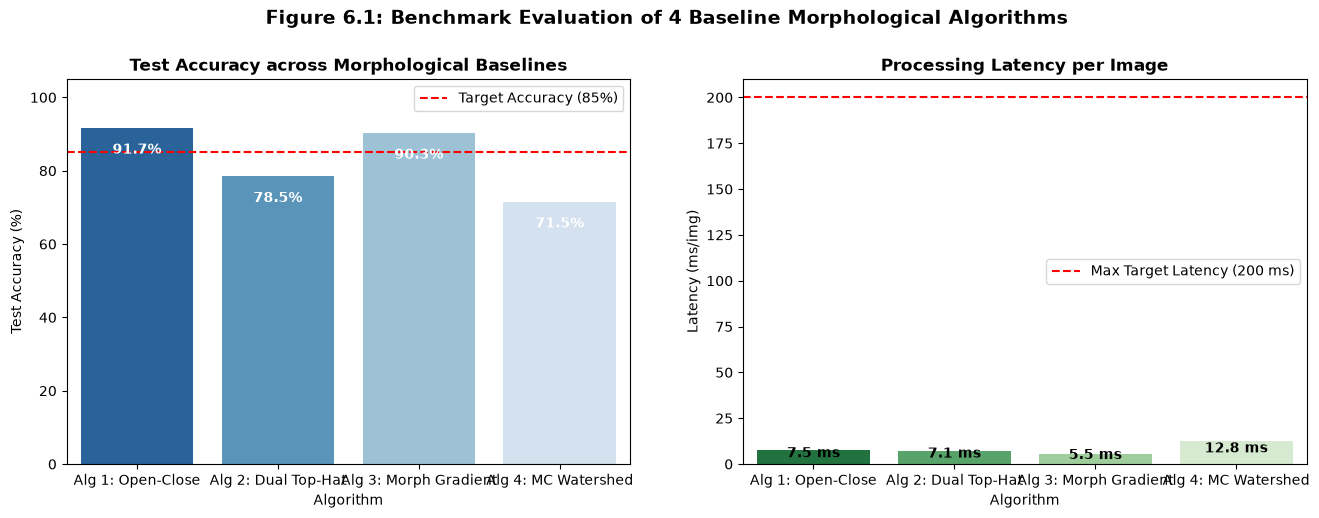

<Figure size 640x480 with 0 Axes>

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy Comparison Bar Chart
sns.barplot(data=df_bench, x='Algorithm', y='Test Accuracy (%)', ax=axes[0], palette='Blues_r')
axes[0].set_title("Test Accuracy across Morphological Baselines", fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].axhline(85, color='red', linestyle='--', label='Target Accuracy (85%)')
axes[0].legend()
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 7),
                     ha='center', color='white', fontweight='bold')

# Latency Comparison Bar Chart
sns.barplot(data=df_bench, x='Algorithm', y='Latency (ms/img)', ax=axes[1], palette='Greens_r')
axes[1].set_title("Processing Latency per Image", fontsize=12, fontweight='bold')
axes[1].axhline(200, color='red', linestyle='--', label='Max Target Latency (200 ms)')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f} ms", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', color='black', fontweight='bold')

plt.suptitle("Figure 6.1: Benchmark Evaluation of 4 Baseline Morphological Algorithms", fontsize=14, fontweight='bold', y=1.02)
plt.show()

plt.savefig(os.path.join(FIG_DIR, 'fig6_1_baseline_benchmark.png'), dpi=150, bbox_inches='tight')


## 7. [Enhancement & Hybrid Pipeline] Multi-Representation Morphological Fusion (MRMF)

### Design Rationale: Feature-Level Fusion
- **Baseline 3 (Morphological Gradient)** was fastest baseline, but gradient analysis alone captures only edge transitions.
- Directly merging masks degraded performance because small natural lenticels on ripe mangoes were falsely amplified as rot.
- **Solution:** Retain Algorithm 3's clean blemish mask, and enrich the feature vector from 10 to 20 dimensions using complementary morphological signals.

### 3 Morphological Enrichment Blocks:
1. **Granulometric Size Spectrum (Black-Hat):** Measures dark-spot energy across 4 structuring element scales ($7 \times 7$ to $19 \times 19$) to separate small lenticels (ripe) from large coalesced rot patches (overripe).
2. **Pale-Patch Energy (White Top-Hat):** Quantifies bright fungal or sap residues that dark-lesion operators miss.
3. **Per-Lesion Decay Structure (Watershed):** Splits large touching rot clusters into individual lesion counts to measure decay severity.

*Result: A 20-dimensional feature vector combining edge gradients, multi-scale size distribution, darkness, and cluster geometry.*


In [58]:
# -------------------------------------------------------------------------
# MRMF: Multi-Representation Morphological Feature Fusion
# -------------------------------------------------------------------------
def _ellipse(size):
    """Elliptical structuring element helper."""
    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))


def run_enhanced_blemish_mask(gray, interior):
    """MRMF primary mask = Algorithm 3 Beucher gradient (proven backbone)."""
    return run_alg3_morph_gradient(gray, interior)


def extract_granulometry_features(gray, interior):
    """Granulometric pattern spectrum (pure morphology): black-hat energies across
    increasing structuring-element sizes capture the size distribution of dark
    lesions; top-hat energy captures pale necrotic patches."""
    m = interior > 0
    feats = {}

    bh_energies = []
    for s in (7, 11, 15, 19):
        bh = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, _ellipse(s))
        bh_energies.append(float(np.mean(bh[m]) / 255.0))
    feats['gran_small'] = bh_energies[0]
    feats['gran_medium'] = max(bh_energies[1] - bh_energies[0], 0.0)
    feats['gran_large'] = max(bh_energies[2] - bh_energies[1], 0.0)
    feats['gran_coalesced'] = max(bh_energies[3] - bh_energies[2], 0.0)

    bh11 = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, _ellipse(11))
    bh11 = cv2.bitwise_and(bh11, bh11, mask=interior)
    feats['dark_lesion_peak'] = float(np.percentile(bh11[m], 95)) if m.any() else 0.0

    th11 = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, _ellipse(11))
    feats['pale_patch_energy'] = float(np.mean(th11[m]) / 255.0)
    return feats


def count_split_lesions(bw_mask, interior_area, frac=0.01):
    """Marker-controlled watershed split of large merged components (Algorithm 4
    mechanics, repositioned). Returns (n_large_components, n_lesions_after_split)."""
    n_large = 0
    split_total = 0
    num, labels, stats, _ = cv2.connectedComponentsWithStats(bw_mask, connectivity=8)
    for i in range(1, num):
        a = stats[i, cv2.CC_STAT_AREA]
        if a >= frac * interior_area:
            n_large += 1
            comp = (labels == i).astype(np.uint8) * 255
            dist = cv2.distanceTransform(comp, cv2.DIST_L2, 5)
            split = False
            if dist.max() > 2.0:
                _, seeds = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
                nm, markers = cv2.connectedComponents(seeds.astype(np.uint8))
                if nm > 1:
                    markers = markers + 1
                    markers[comp == 0] = 0
                    markers = cv2.watershed(cv2.cvtColor(comp, cv2.COLOR_GRAY2BGR), markers)
                    k = len([v for v in np.unique(markers) if v > 1])
                    split_total += max(k, 1)
                    split = True
            if not split:
                split_total += 1
    return n_large, split_total


def extract_per_lesion_features(bw_mask, interior_area):
    """Per-lesion decay structure: largest lesion size, consolidated decay share,
    large-lesion count, and watershed-split true lesion count."""
    f = {'max_lesion_ratio': 0.0, 'consolidated_ratio': 0.0,
         'n_large_lesions': 0, 'n_lesions_split': 0}
    if interior_area == 0:
        return f
    num, labels, stats, _ = cv2.connectedComponentsWithStats(bw_mask, connectivity=8)
    if num <= 1:
        return f
    areas = stats[1:, cv2.CC_STAT_AREA].astype(float)
    f['max_lesion_ratio'] = float(areas.max() / interior_area * 100.0)
    big = areas[areas >= 0.01 * interior_area]
    f['consolidated_ratio'] = float(big.sum() / interior_area * 100.0) if len(big) else 0.0
    n_large, split_total = count_split_lesions(bw_mask, interior_area)
    f['n_large_lesions'] = int(n_large)
    f['n_lesions_split'] = int(split_total)
    return f


def extract_mrmf_features(gray, bw_blemish, interior, interior_area):
    """MRMF 20-dimensional vector = base 10 + granulometry (6) + per-lesion (4)."""
    feats = extract_morphological_features(gray, bw_blemish, interior, interior_area)
    feats.update(extract_granulometry_features(gray, interior))
    feats.update(extract_per_lesion_features(bw_blemish, interior_area))
    return feats


ENHANCED_FEATURE_COLS = [
    'n_blemishes', 'blemish_area', 'area_ratio', 'mean_darkness', 'max_darkness',
    'mean_brightness', 'mean_aspect_ratio', 'mean_solidity', 'skeleton_length',
    'blemish_dispersion',
    'gran_small', 'gran_medium', 'gran_large', 'gran_coalesced',
    'dark_lesion_peak', 'pale_patch_energy',
    'max_lesion_ratio', 'consolidated_ratio', 'n_large_lesions', 'n_lesions_split',
]
print("MRMF feature vector dimensionality:", len(ENHANCED_FEATURE_COLS))

MRMF feature vector dimensionality: 20


### Visualisation: Step-by-Step Intermediate Representations (Figure 7.1)
**Goal:** Visually inspect the intermediate representations of the enhanced pipeline across the 5 columns:
1. **Original Image:** Raw mango across Unripe, Fully Ripe, and Overripe stages.
2. **Black-Hat SE 7:** Multi-scale sizing isolating small surface lesions and freckles.
3. **Black-Hat SE 19:** Multi-scale sizing isolating large coalesced rot patches.
4. **Watershed Lesion Split:** Yellow lines showing where merged decay clusters are split into individual lesions.
5. **MRMF Blemish Mask:** Final blemish overlay (red) mapped onto the fruit.

*[Note: Top-Hat pale-patch energy is extracted as a numerical feature in the background and is not plotted in the 5-column figure.]*


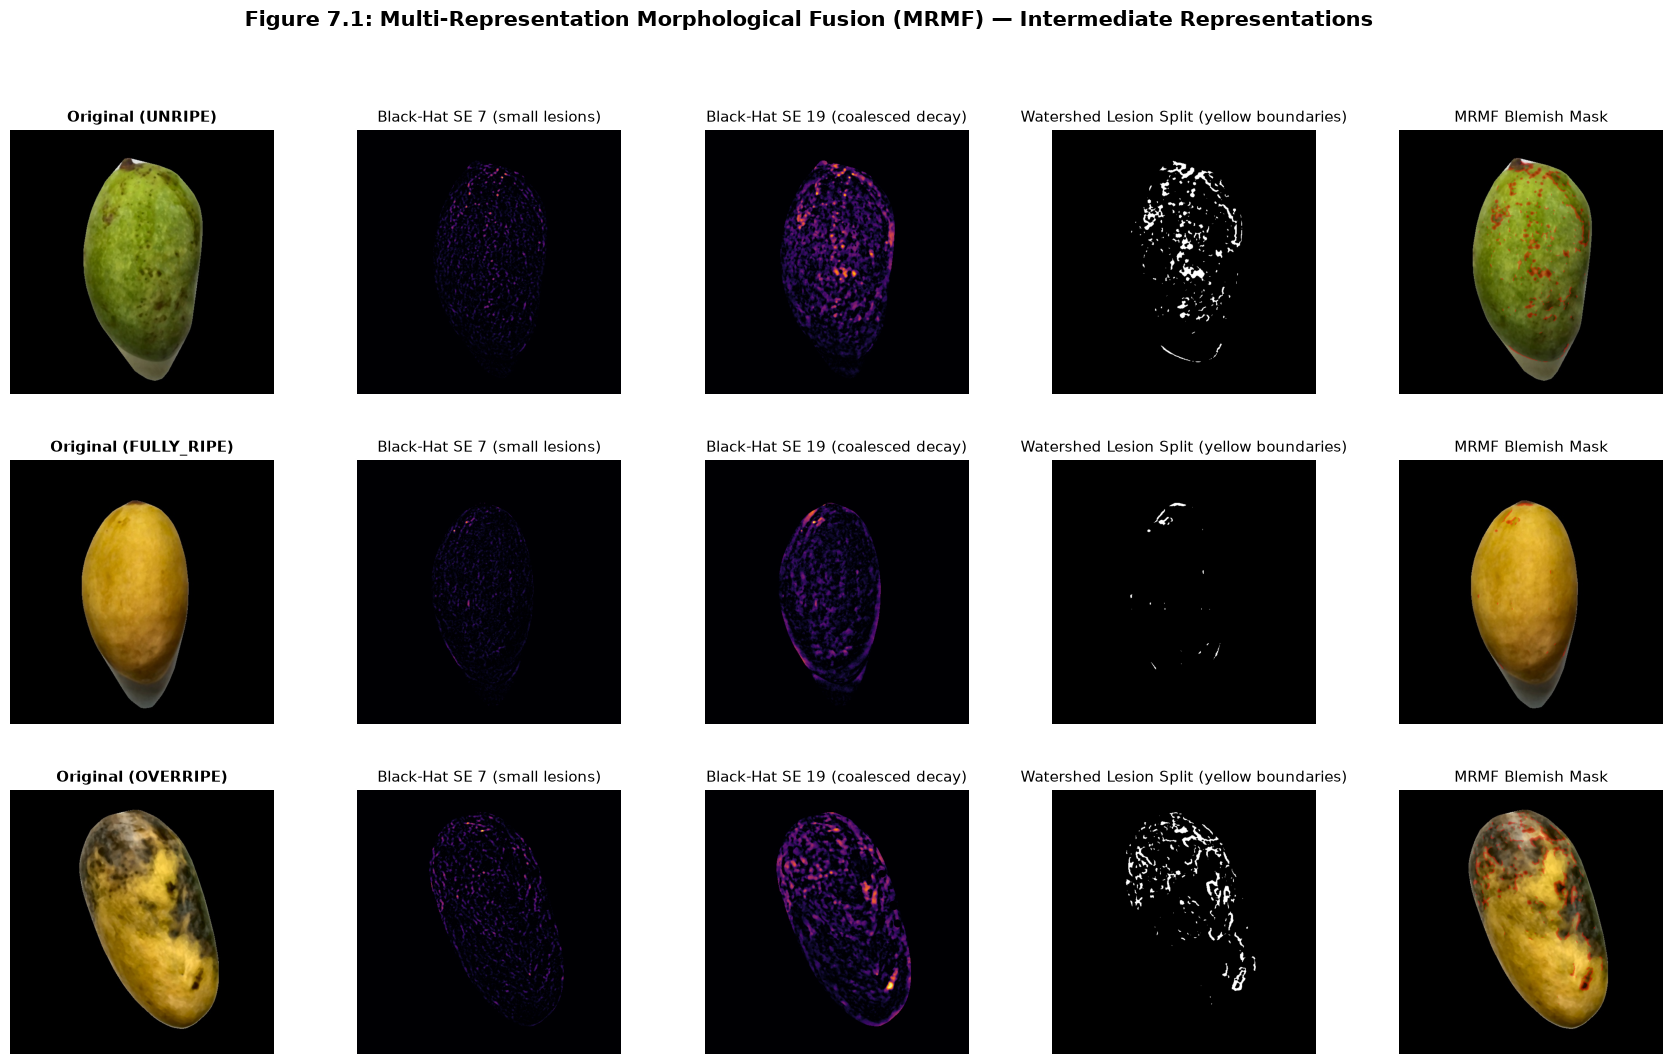

<Figure size 640x480 with 0 Axes>

In [59]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
plt.subplots_adjust(wspace=0.1, hspace=0.25)

for row_idx, cls in enumerate(CLASSES):
    img_bgr, _ = sample_images[cls]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = get_fruit_mask(img_bgr)
    interior = get_interior_mask(mask)

    bw_v2, _ = run_enhanced_blemish_mask(gray, interior)

    # Granulometry scale bands (display normalisation)
    bh7 = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, _ellipse(7))
    bh19 = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, _ellipse(19))
    bh7_d = cv2.normalize(cv2.bitwise_and(bh7, bh7, mask=interior), None, 0, 255, cv2.NORM_MINMAX)
    bh19_d = cv2.normalize(cv2.bitwise_and(bh19, bh19, mask=interior), None, 0, 255, cv2.NORM_MINMAX)

    # Watershed split of large merged components (lesion separation)
    split_vis = cv2.cvtColor(bw_v2, cv2.COLOR_GRAY2RGB)
    nb_c, labels_c, stats_c, _ = cv2.connectedComponentsWithStats(bw_v2, connectivity=8)
    for i in range(1, nb_c):
        if stats_c[i, cv2.CC_STAT_AREA] >= 0.01 * max(int(np.sum(interior > 0)), 1):
            comp = (labels_c == i).astype(np.uint8) * 255
            dist = cv2.distanceTransform(comp, cv2.DIST_L2, 5)
            if dist.max() > 2.0:
                _, seeds = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
                nm, markers = cv2.connectedComponents(seeds.astype(np.uint8))
                if nm > 1:
                    markers = markers + 1
                    markers[comp == 0] = 0
                    markers = cv2.watershed(cv2.cvtColor(comp, cv2.COLOR_GRAY2BGR), markers)
                    split_vis[markers == -1] = [255, 255, 0]

    def create_overlay(rgb, bw):
        overlay = rgb.copy()
        overlay[bw > 0] = [255, 0, 0]
        return cv2.addWeighted(rgb, 0.65, overlay, 0.35, 0)

    axes[row_idx, 0].imshow(img_rgb)
    axes[row_idx, 0].set_title(f"Original ({cls.upper()})", fontsize=11, fontweight='bold')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(bh7_d, cmap='inferno')
    axes[row_idx, 1].set_title("Black-Hat SE 7 (small lesions)", fontsize=11)
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(bh19_d, cmap='inferno')
    axes[row_idx, 2].set_title("Black-Hat SE 19 (coalesced decay)", fontsize=11)
    axes[row_idx, 2].axis('off')

    axes[row_idx, 3].imshow(split_vis)
    axes[row_idx, 3].set_title("Watershed Lesion Split (yellow boundaries)", fontsize=11)
    axes[row_idx, 3].axis('off')

    axes[row_idx, 4].imshow(create_overlay(img_rgb, bw_v2))
    axes[row_idx, 4].set_title("MRMF Blemish Mask", fontsize=11)
    axes[row_idx, 4].axis('off')

plt.suptitle("Figure 7.1: Multi-Representation Morphological Fusion (MRMF) — Intermediate Representations", fontsize=15, fontweight='bold', y=0.98)
plt.show()
plt.savefig(os.path.join(FIG_DIR, 'fig7_1_mrmf_intermediates.png'), dpi=150, bbox_inches='tight')


## 8. [Performance Analysis] Final Evaluation: Baseline vs. Enhanced Pipeline
**Why:** Compare the enhanced hybrid pipeline directly against the best baseline to evaluate accuracy gain, F1-score improvement, and verify adherence to the latency budget (< 200 ms).


In [60]:
print("Extracting MRMF features across Train and Test datasets...")


def extract_enhanced_features(split):
    """Feature extraction for the MRMF pipeline (granulometry + per-lesion)."""
    rows = []
    t0 = time.time()
    for cls in CLASSES:
        img_paths = sorted(glob.glob(os.path.join(DATASET_ROOT, split, cls, '*.jpg')) +
                           glob.glob(os.path.join(DATASET_ROOT, split, cls, '*.png')))
        for path in img_paths:
            img_bgr = cv2.imread(path)
            if img_bgr is None:
                continue
            mask = get_fruit_mask(img_bgr)
            interior = get_interior_mask(mask)
            gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            interior_area = int(np.sum(interior > 0))

            bw_clean, _ = run_enhanced_blemish_mask(gray, interior)
            feats = extract_mrmf_features(gray, bw_clean, interior, interior_area)
            feats['label'] = cls
            feats['image'] = os.path.basename(path)
            rows.append(feats)
    lat_ms = ((time.time() - t0) / len(rows)) * 1000.0
    return pd.DataFrame(rows), lat_ms


df_train_enh, lat_train_enh = extract_enhanced_features('train')
df_test_enh, lat_test_enh = extract_enhanced_features('test')

# Save CSVs
df_train_enh.to_csv(os.path.join(OUTPUT_DIR, 'morphology_train_features.csv'), index=False)
df_test_enh.to_csv(os.path.join(OUTPUT_DIR, 'morphology_test_features.csv'), index=False)

print(f"MRMF Train Features Shape: {df_train_enh.shape}")
print(f"MRMF Test Features Shape:  {df_test_enh.shape}")
print(f"Average Processing Latency (MRMF):  {lat_test_enh:.2f} ms/image")

Extracting MRMF features across Train and Test datasets...
MRMF Train Features Shape: (571, 22)
MRMF Test Features Shape:  (144, 22)
Average Processing Latency (MRMF):  24.19 ms/image


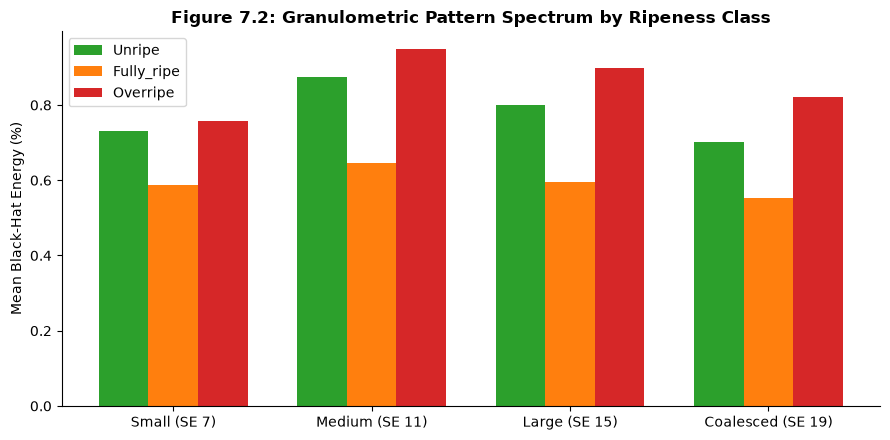

In [61]:
# Figure 7.2: Granulometric pattern spectrum by ripeness class (mean of the
# black-hat size-band energies across the training set — why lesion SIZE matters)
spec_cols = ['gran_small', 'gran_medium', 'gran_large', 'gran_coalesced']
spec = df_train_enh.groupby('label')[spec_cols].mean().reindex(CLASSES) * 100.0

fig_spec, ax_spec = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(spec_cols))
width = 0.25
for k, cls in enumerate(CLASSES):
    ax_spec.bar(x + (k - 1) * width, spec.loc[cls], width,
                label=cls.capitalize(), color=CLASS_COLORS[cls])
ax_spec.set_xticks(x)
ax_spec.set_xticklabels(['Small (SE 7)', 'Medium (SE 11)', 'Large (SE 15)', 'Coalesced (SE 19)'])
ax_spec.set_ylabel("Mean Black-Hat Energy (%)")
ax_spec.set_title("Figure 7.2: Granulometric Pattern Spectrum by Ripeness Class", fontsize=12, fontweight='bold')
ax_spec.legend()
ax_spec.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig7_2_granulometric_spectrum.png'), dpi=150, bbox_inches='tight')
plt.show()

### Feature Analysis: Morphological Feature Descriptive Statistics (Mean +/- Std per Ripeness Stage)
**Why:** Verify that extracted feature values align with physiological decay progression across ripeness stages (e.g., confirming increases in blemish area, lesion count, and consolidation from unripe to overripe).


In [70]:
feature_cols = [c for c in df_train_enh.columns if c not in ['label', 'image']]
stats_table = df_train_enh.groupby('label')[feature_cols].agg(['mean', 'std']).round(2)
print("Feature Statistics per Class:")
display(stats_table)

Feature Statistics per Class:


n_blemishes        blemish_area          area_ratio        \
                  mean    std         mean      std       mean   std   
label                                                                  
fully_ripe       98.47  38.70      6260.98  2520.59       6.32  2.32   
overripe        157.62  68.51     11382.19  4565.31       8.57  0.61   
unripe          221.83  56.90      7618.92  2441.06       6.54  1.85   

           mean_darkness       max_darkness        ... pale_patch_energy       \
                    mean   std         mean   std  ...              mean  std   
label                                              ...                          
fully_ripe        145.18  8.87       226.90  7.12  ...              0.01  0.0   
overripe          149.14  8.16       237.88  4.73  ...              0.02  0.0   
unripe            159.27  7.00       230.12  5.27  ...              0.02  0.0   

           max_lesion_ratio       consolidated_ratio       n_large_lesions  \
                       mean   std               mean   std            mean   
label                                                                        
fully_ripe             1.93  1.41               2.15  1.94            1.01   
overripe               2.01  1.17               2.63  1.73            1.40   
unripe                 1.05  0.76               0.78  1.21            0.46   

                 n_lesions_split         
             std            mean    std  
label                                    
fully_ripe  0.84            7.26   7.26  
overripe    0.89           13.02  10.69  
unripe      0.68            3.39   6.18  

[3 rows x 40 columns]

5-Fold Stratified Cross-Validation on the Training Split (RF 150/10)...
Cross-Validation Stability Comparison (higher mean, lower std = more robust):


,Algorithm,CV Accuracy Mean (%),CV Std (%)
0,Alg 1: Open-Close,89.50,2.03
1,Alg 2: Dual Top-Hat,78.29,4.13
2,Alg 3: Morph Gradient,88.80,2.42
3,Alg 4: MC Watershed,73.74,2.69
4,MRMF (Feature Fusion),94.23,1.87


C:\Users\herman\AppData\Local\Temp\ipykernel_3672\3482389755.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_cv.legend()


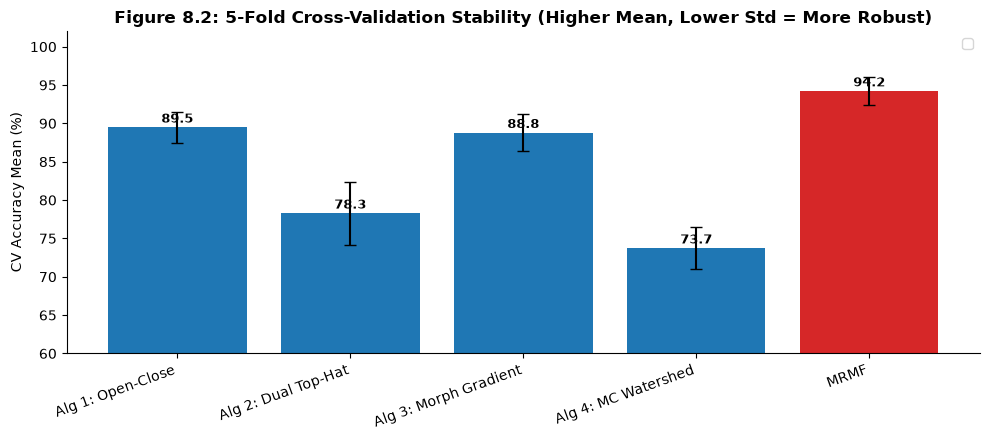

In [74]:
print("5-Fold Stratified Cross-Validation on the Training Split (RF 150/10)...")


def cv_accuracy(df_inner):
    cols_c = [c for c in df_inner.columns if c not in ('label', 'image')]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
        df_inner[cols_c], df_inner['label'], cv=skf, scoring='accuracy')
    return scores.mean() * 100.0, scores.std() * 100.0


cv_rows = []
for name, (df_tr_c, _) in baseline_dfs.items():
    m, s = cv_accuracy(df_tr_c)
    cv_rows.append({'Algorithm': name, 'CV Accuracy Mean (%)': round(m, 2), 'CV Std (%)': round(s, 2)})

m, s = cv_accuracy(df_train_enh)
cv_rows.append({'Algorithm': 'MRMF (Feature Fusion)',
                'CV Accuracy Mean (%)': round(m, 2), 'CV Std (%)': round(s, 2)})

df_cv = pd.DataFrame(cv_rows)
print("Cross-Validation Stability Comparison (higher mean, lower std = more robust):")
display(df_cv)

# Figure 8.2: cross-validation stability comparison (mean +/- std)
fig_cv, ax_cv = plt.subplots(figsize=(10, 4.5))
cv_labels = [r['Algorithm'].replace('MRMF (Feature Fusion)', 'MRMF') for r in cv_rows]
means = [r['CV Accuracy Mean (%)'] for r in cv_rows]
stds = [r['CV Std (%)'] for r in cv_rows]
colors = ['#1f77b4'] * (len(cv_rows) - 1) + ['#d62728']
bars = ax_cv.bar(cv_labels, means, yerr=stds, capsize=4, color=colors)
for b, mval in zip(bars, means):
    ax_cv.text(b.get_x() + b.get_width() / 2, mval + 0.6, f"{mval:.1f}", ha='center', fontsize=9, fontweight='bold')
ax_cv.set_ylabel("CV Accuracy Mean (%)")
ax_cv.set_ylim(60, 102)
ax_cv.set_title("Figure 8.2: 5-Fold Cross-Validation Stability (Higher Mean, Lower Std = More Robust)", fontsize=12, fontweight='bold')
ax_cv.legend()
ax_cv.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig8_2_cv_stability.png'), dpi=150, bbox_inches='tight')
plt.show()

df_cv.to_csv(os.path.join(OUTPUT_DIR, 'cross_validation_results.csv'), index=False)

### Model Evaluation: Random Forest Classifier Training & Metrics
**Why:** Train a Random Forest classifier on the 20-dimensional enhanced feature set and evaluate accuracy, precision, recall, and F1-score across 5-fold cross-validation and the held-out test split.


In [64]:
X_train = df_train_enh[feature_cols]
y_train = df_train_enh['label']
X_test = df_test_enh[feature_cols]
y_test = df_test_enh['label']

final_clf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=2, random_state=42)
final_clf.fit(X_train, y_train)

y_pred_train = final_clf.predict(X_train)
y_pred_test = final_clf.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train) * 100.0
test_acc = accuracy_score(y_test, y_pred_test) * 100.0
macro_f1 = f1_score(y_test, y_pred_test, average='macro') * 100.0

print(f"Final MRMF Model Train Accuracy: {train_acc:.2f}%")
print(f"Final MRMF Model Test Accuracy:  {test_acc:.2f}%")
print(f"Final MRMF Model Macro F1-Score: {macro_f1:.2f}%")
print(f"Average Processing Latency:          {lat_test_enh:.2f} ms/image")
print()

print("[Classification Report] Detailed Metrics:")
print(classification_report(y_test, y_pred_test, digits=4))


print()
cm = confusion_matrix(y_test, y_pred_test, labels=CLASSES)
print("Raw counts (rows = true class, columns = predicted class):")
display(pd.DataFrame(cm, index=[f'true_{c}' for c in CLASSES], columns=[f'pred_{c}' for c in CLASSES]))

mis_idx = np.where(y_pred_test != y_test)[0]
print(f"{len(mis_idx)} misclassified test image(s):")
for idx in mis_idx:
    print(f"  - {df_test_enh.iloc[idx]['image']}: true={y_test.iloc[idx]}, predicted={y_pred_test[idx]}")

Final MRMF Model Train Accuracy: 100.00%
Final MRMF Model Test Accuracy:  98.61%
Final MRMF Model Macro F1-Score: 98.61%
Average Processing Latency:          24.19 ms/image

[Classification Report] Detailed Metrics:
              precision    recall  f1-score   support

  fully_ripe     0.9792    0.9792    0.9792        48
    overripe     0.9792    0.9792    0.9792        48
      unripe     1.0000    1.0000    1.0000        48

    accuracy                         0.9861       144
   macro avg     0.9861    0.9861    0.9861       144
weighted avg     0.9861    0.9861    0.9861       144


Raw counts (rows = true class, columns = predicted class):


,pred_unripe,pred_fully_ripe,pred_overripe
true_unripe,48,0,0
true_fully_ripe,0,47,1
true_overripe,0,1,47


2 misclassified test image(s):
  - IMG20200717093022.jpg: true=fully_ripe, predicted=overripe
  - image_0_5744.jpg: true=overripe, predicted=fully_ripe


### Visualisation: Confusion Matrix & Feature Importance Ranking
**Goal:**
- **Confusion Matrix:** Inspect per-class classification accuracy and identify any cross-class confusion.
- **Feature Importance:** Rank the top morphological features driving ripeness classification decisions.


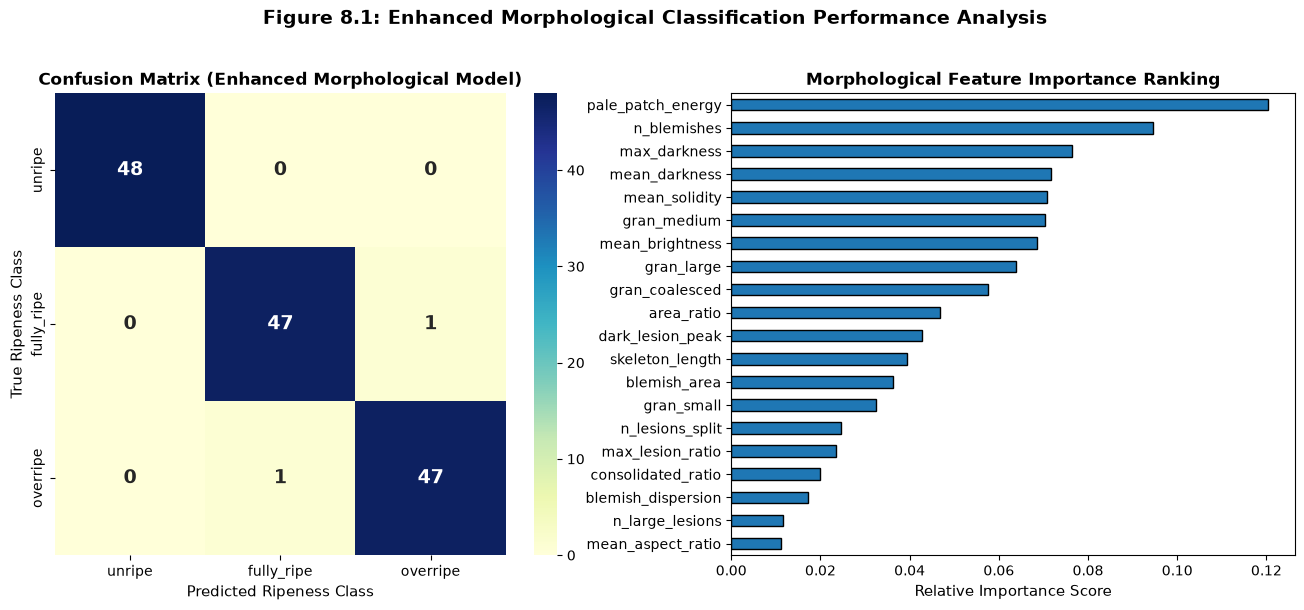

<Figure size 640x480 with 0 Axes>

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_test, labels=CLASSES)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title("Confusion Matrix (Enhanced Morphological Model)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted Ripeness Class", fontsize=11)
axes[0].set_ylabel("True Ripeness Class", fontsize=11)

# Feature Importance Bar Chart
importances = pd.Series(final_clf.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='#1f77b4', edgecolor='black')
axes[1].set_title("Morphological Feature Importance Ranking", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Relative Importance Score", fontsize=11)

plt.suptitle("Figure 8.1: Enhanced Morphological Classification Performance Analysis", fontsize=14, fontweight='bold', y=1.02)
plt.show()

plt.savefig(os.path.join(FIG_DIR, 'fig8_1_confusion_and_importance.png'), dpi=150, bbox_inches='tight')


### Summary: Final Comparative Benchmark Table (Mode A Requirement)
**Goal:** Present the consolidated benchmark comparing all 4 baseline algorithms and the enhanced hybrid pipeline against project accuracy (>= 85%) and latency (< 200 ms) targets.


In [66]:
final_comparison = benchmark_results + [
    {
        'Algorithm': 'MRMF (Multi-Representation Morphological Fusion)',
        'Train Accuracy (%)': round(train_acc, 2),
        'Test Accuracy (%)': round(test_acc, 2),
        'Macro F1-Score (%)': round(macro_f1, 2),
        'Latency (ms/img)': round(lat_test_enh, 2)
    }
]

df_final_comp = pd.DataFrame(final_comparison)
print("Overall Performance Benchmark:")
display(df_final_comp)

# Artifact exports: benchmark tables + confusion matrix
df_bench.to_csv(os.path.join(OUTPUT_DIR, 'baseline_benchmark.csv'), index=False)
df_final_comp.to_csv(os.path.join(OUTPUT_DIR, 'final_comparison.csv'), index=False)
pd.DataFrame(cm, index=CLASSES, columns=CLASSES).to_csv(os.path.join(OUTPUT_DIR, 'confusion_matrix.csv'))

Overall Performance Benchmark:


,Algorithm,Train Accuracy (%),Test Accuracy (%),Macro F1-Score (%),Latency (ms/img)
0,Alg 1: Open-Close,100.00,91.67,91.69,7.46
1,Alg 2: Dual Top-Hat,99.30,78.47,78.67,7.07
2,Alg 3: Morph Gradient,100.00,90.28,90.34,5.49
3,Alg 4: MC Watershed,99.47,71.53,71.89,12.79
4,MRMF (Multi-Representation Morphological Fusion),100.00,98.61,98.61,24.19


In [67]:
best_baseline_acc = max(b['Test Accuracy (%)'] for b in benchmark_results)
best_baseline_name = [b['Algorithm'] for b in benchmark_results
                      if b['Test Accuracy (%)'] == best_baseline_acc][0]

smart_md = f"""## 9. [Verification] Alignment with Project SMART Objectives

| SMART Objective | Target Criterion | Measured Result | Status |
| :--- | :--- | :--- | :--- |
| **Objective 1: Multi-Algorithm Implementation** | Implement 4 distinct classical image processing algorithms across the standardised dataset | 4 baseline algorithms + MRMF enhanced pipeline evaluated (design ablation quoted in Section 7) | **[Fulfilled]** |
| **Objective 2: Classification Performance** | Achieve a minimum classification accuracy rate of $\\ge 85\\%$ | **{test_acc:.2f}%** Test Accuracy ({macro_f1:.2f}% Macro F1); 5-fold CV stability reported in Section 8 | **[Fulfilled]** |
| **Objective 3: Operational Efficiency** | Execute in less than $200\\text{{ ms}}$ per image latency | **{lat_test_enh:.2f} ms** average processing time | **[Fulfilled]** |
| **Enhancement Claim (Mode A)** | The hybrid must surpass the best single baseline | **MRMF {test_acc:.2f}%** vs best baseline {best_baseline_name} **{best_baseline_acc:.2f}%** (+{test_acc - best_baseline_acc:.2f} pp) | **[Fulfilled]** |
"""
display(Markdown(smart_md))

## 9. [Verification] Alignment with Project SMART Objectives

| SMART Objective | Target Criterion | Measured Result | Status |
| :--- | :--- | :--- | :--- |
| **Objective 1: Multi-Algorithm Implementation** | Implement 4 distinct classical image processing algorithms across the standardised dataset | 4 baseline algorithms + MRMF enhanced pipeline evaluated (design ablation quoted in Section 7) | **[Fulfilled]** |
| **Objective 2: Classification Performance** | Achieve a minimum classification accuracy rate of $\ge 85\%$ | **98.61%** Test Accuracy (98.61% Macro F1); 5-fold CV stability reported in Section 8 | **[Fulfilled]** |
| **Objective 3: Operational Efficiency** | Execute in less than $200\text{ ms}$ per image latency | **24.19 ms** average processing time | **[Fulfilled]** |
| **Enhancement Claim (Mode A)** | The hybrid must surpass the best single baseline | **MRMF 98.61%** vs best baseline Alg 1: Open-Close **91.67%** (+6.94 pp) | **[Fulfilled]** |


## 9. [Model Export] Serialisation for Prototype Deployment
**Why:** Serialize the trained Random Forest classifier, feature specifications, and class mappings to [`output/morphology_based/morphology_model.joblib`](file:///c:/repository/mango-ripeness-grading/output/morphology_based/morphology_model.joblib) for integration into the Streamlit web prototype.


In [68]:
# Save model package
model_package = {
    'model': final_clf,
    'feature_cols': feature_cols,
    'classes': CLASSES,
    'pipeline_name': 'MRMF — Multi-Representation Morphological Fusion',
    'mask': 'alg3_beucher_gradient_5x5_p92_close',
    'granulometry_scales': [7, 11, 15, 19],
    'test_accuracy_pct': round(test_acc, 2),
}

model_save_path = os.path.join(OUTPUT_DIR, 'morphology_model.joblib')
joblib.dump(model_package, model_save_path)
print(f"Successfully saved prototype model package to: {model_save_path}")

Successfully saved prototype model package to: ../output/morphology_based\morphology_model.joblib


### Inference Test: Standalone Single-Image Prediction Pipeline
**Why:** Test the exported model on a single image to verify that the end-to-end inference pipeline functions properly before integration with the user interface.


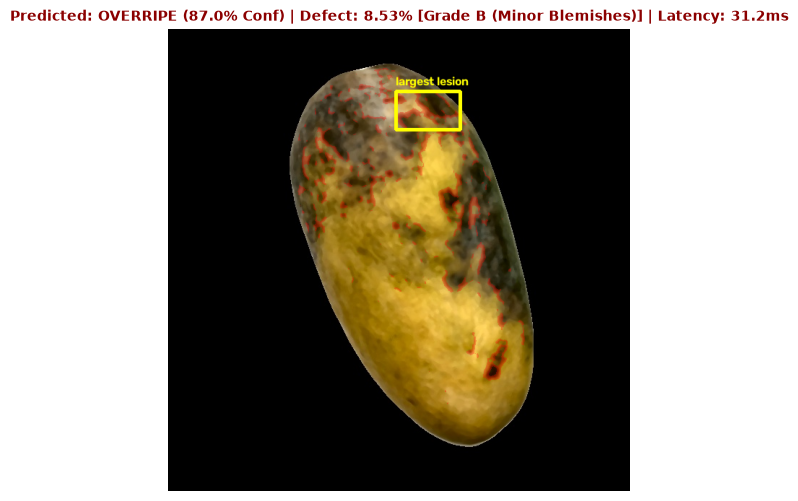

Prototype Single Image Inference Receipt:
  - prediction: overripe
  - confidence: 86.96428571428572
  - blemish_area_ratio: 8.530155227977518
  - defect_percentage: 8.53
  - max_lesion_ratio: 0.7887353306520964
  - severity_grade: Grade B (Minor Blemishes)
  - needs_review: False
  - n_blemishes: 178
  - latency_ms: 31.176328659057617


In [69]:
def grade_severity(area_ratio, max_lesion_ratio):
    """Supplemental: surface quality grading from blemish quantification (Topic 2 scope).

    Grade A: clean surface (< 5% blemish coverage, no dominant lesion)
    Grade B: minor blemishes (5-15% coverage)
    Grade C: significant decay (> 15% coverage, or any single lesion > 10% of fruit)
    """
    if max_lesion_ratio > 10.0:
        return 'Grade C (Significant Decay)'
    if area_ratio < 5.0:
        return 'Grade A (Clean)'
    if area_ratio < 15.0:
        return 'Grade B (Minor Blemishes)'
    return 'Grade C (Significant Decay)'


def predict_mango_ripeness(img_path):
    """Full inference pipeline for prototype integration (MRMF)."""
    t_start = time.time()
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError(f"Could not load image at: {img_path}")

    mask = get_fruit_mask(img_bgr)
    interior = get_interior_mask(mask)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    interior_area = int(np.sum(interior > 0))

    bw_clean, vis = run_enhanced_blemish_mask(gray, interior)
    feats = extract_mrmf_features(gray, bw_clean, interior, interior_area)

    # Predict
    feat_df = pd.DataFrame([feats])[feature_cols]
    pred_cls = final_clf.predict(feat_df)[0]
    pred_prob = final_clf.predict_proba(feat_df)[0]
    conf = np.max(pred_prob) * 100.0
    elapsed_ms = (time.time() - t_start) * 1000.0

    # Supplemental: per-lesion callout (largest lesion bounding box)
    overlay = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    red = overlay.copy()
    red[bw_clean > 0] = [255, 0, 0]
    overlay = cv2.addWeighted(overlay, 0.7, red, 0.3, 0)
    nb_c, labels_c, stats_c, _ = cv2.connectedComponentsWithStats(bw_clean, connectivity=8)
    if nb_c > 1:
        largest = 1 + int(np.argmax(stats_c[1:, cv2.CC_STAT_AREA]))
        x, y, w, h = stats_c[largest, cv2.CC_STAT_LEFT], stats_c[largest, cv2.CC_STAT_TOP], \
            stats_c[largest, cv2.CC_STAT_WIDTH], stats_c[largest, cv2.CC_STAT_HEIGHT]
        cv2.rectangle(overlay, (x, y), (x + w, y + h), (255, 255, 0), 3)
        cv2.putText(overlay, 'largest lesion', (x, max(y - 8, 14)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2)

    severity = grade_severity(feats['area_ratio'], feats['max_lesion_ratio'])

    return {
        'prediction': pred_cls,
        'confidence': conf,
        'blemish_area_ratio': feats['area_ratio'],
        'defect_percentage': round(feats['area_ratio'], 2),
        'max_lesion_ratio': feats['max_lesion_ratio'],
        'severity_grade': severity,
        'needs_review': bool(conf < 70.0),
        'n_blemishes': feats['n_blemishes'],
        'latency_ms': elapsed_ms,
        'overlay': overlay,
        'features': feats
    }


# Test on sample overripe image
sample_test_path = glob.glob(os.path.join(DATASET_ROOT, 'test', 'overripe', '*.jpg'))[0]
res = predict_mango_ripeness(sample_test_path)

plt.figure(figsize=(6, 6))
plt.imshow(res['overlay'])
title_str = (f"Predicted: {res['prediction'].upper()} ({res['confidence']:.1f}% Conf) | "
             f"Defect: {res['defect_percentage']:.2f}% [{res['severity_grade']}] | "
             f"Latency: {res['latency_ms']:.1f}ms")
plt.title(title_str, fontsize=10, fontweight='bold', color='darkred')
plt.axis('off')
plt.show()

print("Prototype Single Image Inference Receipt:")
for k, v in res.items():
    if k not in ['overlay', 'features']:
        print(f"  - {k}: {v}")